<a href="https://colab.research.google.com/github/jrangelg/Artificial-intelligence/blob/main/Arboles.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Árboles de Clasificación (Classification Trees)

## 1. Introducción

Los **árboles de clasificación** son modelos de aprendizaje supervisado utilizados para predecir una variable categórica a partir de un conjunto de variables explicativas.

Estos modelos pertenecen a la familia de métodos conocidos como **árboles de decisión**, ampliamente utilizados en estadística y *machine learning*.

Un árbol de clasificación divide recursivamente el espacio de las variables explicativas en regiones más pequeñas, con el objetivo de que dentro de cada región las observaciones pertenezcan principalmente a una misma clase.

---

## 2. Estructura de un Árbol

Un árbol de clasificación está compuesto por:

* **Nodo raíz:** punto inicial del árbol que contiene todos los datos.
* **Nodos internos:** representan reglas de partición.
* **Ramas:** resultado de una decisión.
* **Nodos terminales (hojas):** contienen la clasificación final.

Cada nodo aplica una regla del tipo

[
X_j \leq s
]

donde:

* (X_j) es una variable explicativa
* (s) es un punto de corte.

---

## 3. Partición del Espacio

El algoritmo busca particiones del espacio de variables que minimicen la **impureza** de los nodos.

Sea (R_m) la región asociada al nodo (m).

La clase asignada al nodo es

[
\hat{y}*m = \arg\max_k p*{mk}
]

donde

[
p_{mk} = \frac{1}{N_m} \sum_{i \in R_m} I(y_i = k)
]

y:

* (N_m) número de observaciones en el nodo
* (k) clase posible
* (I(\cdot)) función indicadora.

---

## 4. Medidas de Impureza

Para decidir la mejor división del árbol se utilizan medidas de impureza.

### 4.1 Índice de Gini

[
G = \sum_{k=1}^{K} p_{mk}(1-p_{mk})
]

Este índice mide la probabilidad de clasificar incorrectamente una observación si se asigna una clase aleatoriamente según la distribución del nodo.

---

### 4.2 Entropía

[
H = - \sum_{k=1}^{K} p_{mk} \log(p_{mk})
]

La entropía proviene de la teoría de la información y mide el grado de desorden en el nodo.

---

### 4.3 Error de Clasificación

[
E = 1 - \max_k(p_{mk})
]

Esta medida es más simple pero menos sensible que Gini o entropía.

---

## 5. Criterio de División

El algoritmo selecciona la división que minimiza la impureza ponderada:

[
I_{split} =
\frac{N_{left}}{N} I(left)
+
\frac{N_{right}}{N} I(right)
]

donde:

* (I(\cdot)) es una medida de impureza
* (N) número de observaciones en el nodo.

---

## 6. Algoritmo CART

El método más utilizado es **CART (Classification and Regression Trees)**.

El procedimiento es:

1. Iniciar con todos los datos en el nodo raíz.
2. Evaluar todas las divisiones posibles.
3. Seleccionar la división que minimice la impureza.
4. Repetir el proceso recursivamente.
5. Detener cuando se cumpla un criterio de parada.

---

## 7. Poda del Árbol (Pruning)

Los árboles muy grandes pueden **sobreajustar** los datos.

Por ello se utiliza **poda de complejidad de costo**, minimizando:

[
C_\alpha(T) =
\sum_{m=1}^{|T|}
N_m Q_m(T)
+
\alpha |T|
]

donde:

* (Q_m(T)) error en el nodo (m)
* (|T|) número de nodos terminales
* (\alpha) parámetro de penalización.

---

## 8. Ventajas de los Árboles de Clasificación

* Fácil interpretación.
* Manejan relaciones no lineales.
* No requieren supuestos distribucionales.
* Pueden manejar variables categóricas y continuas.

---

## 9. Desventajas

* Alta varianza.
* Sensibles a pequeñas variaciones en los datos.
* Pueden sobreajustar fácilmente.

---

## 10. Métodos Basados en Árboles

Los árboles de clasificación son la base de varios métodos avanzados:

* **Random Forest**
* **Gradient Boosting**
* **XGBoost**
* **Bagging**

Estos métodos combinan múltiples árboles para mejorar la capacidad predictiva.



Los árboles de clasificación constituyen una herramienta fundamental en estadística y aprendizaje automático. Su capacidad para modelar relaciones complejas y su facilidad de interpretación los hacen ampliamente utilizados en problemas de clasificación, especialmente en contextos donde la interpretabilidad es importante.


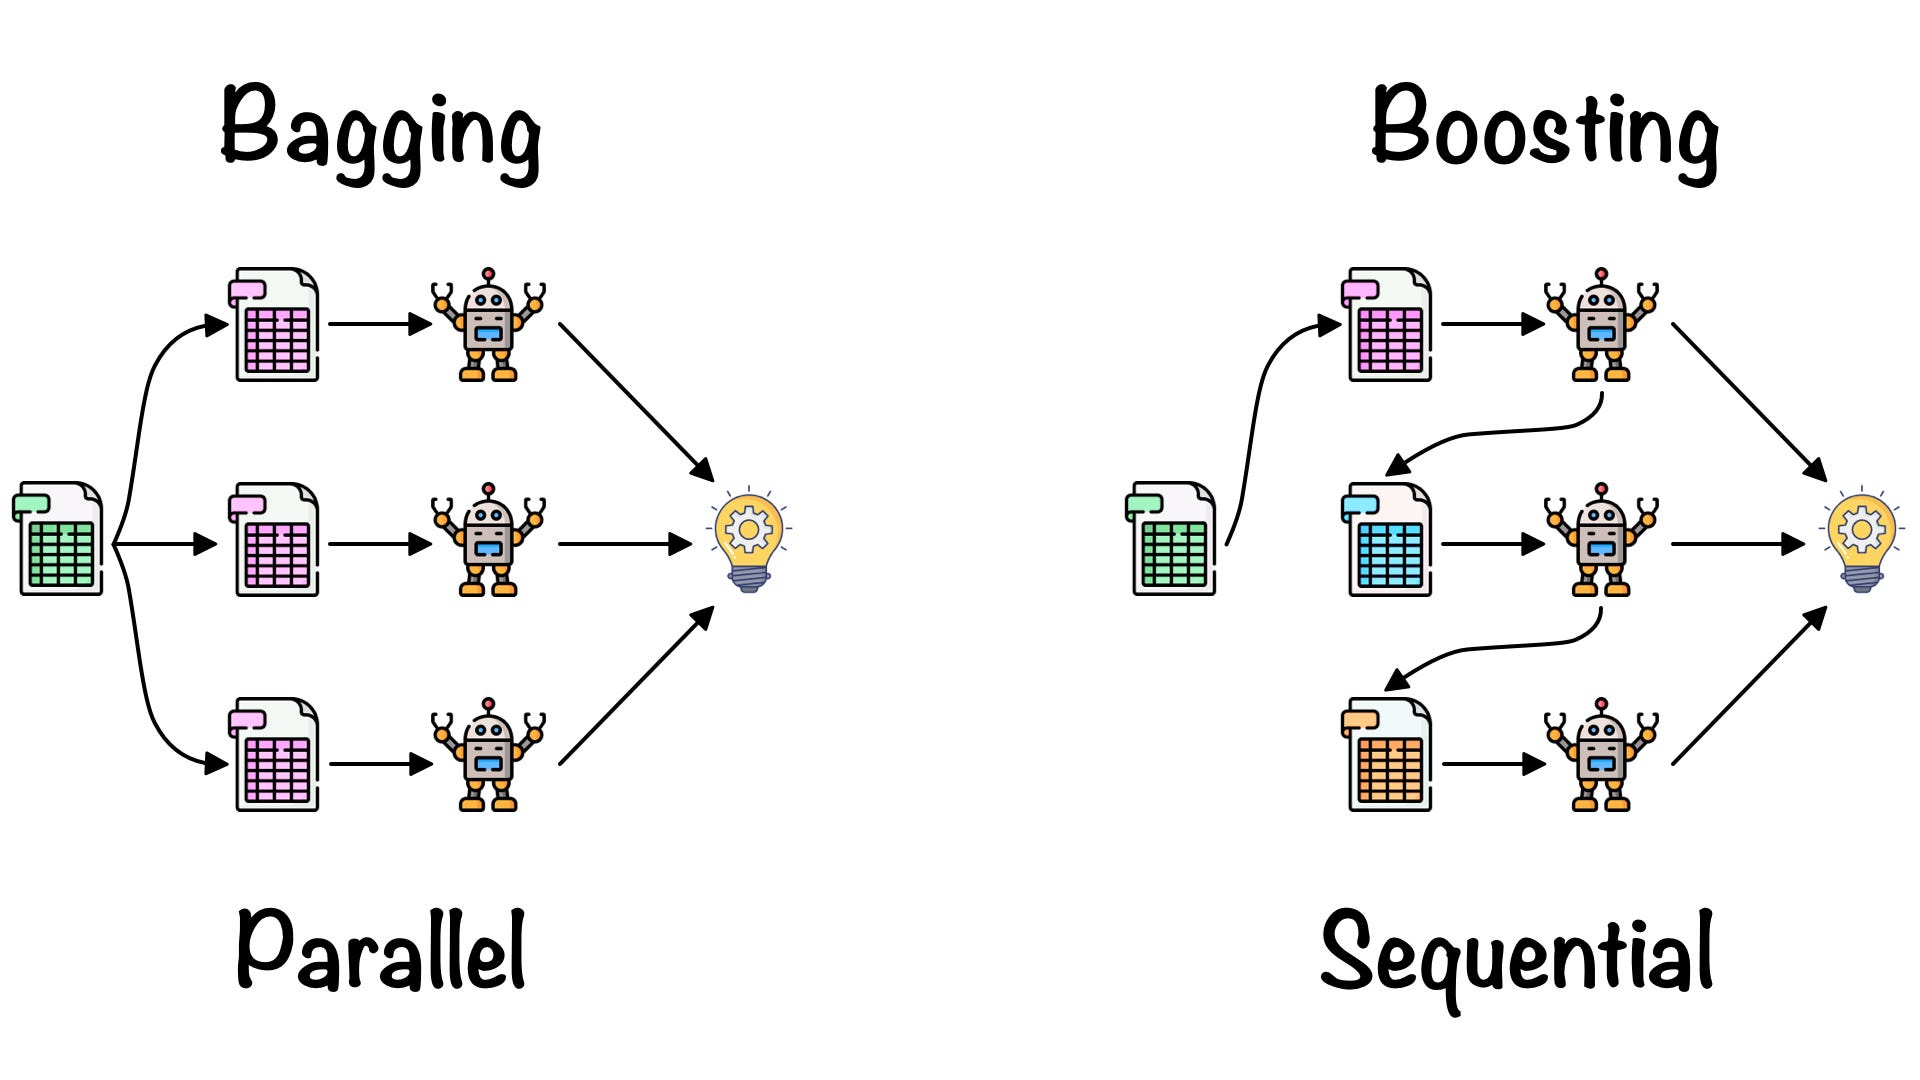

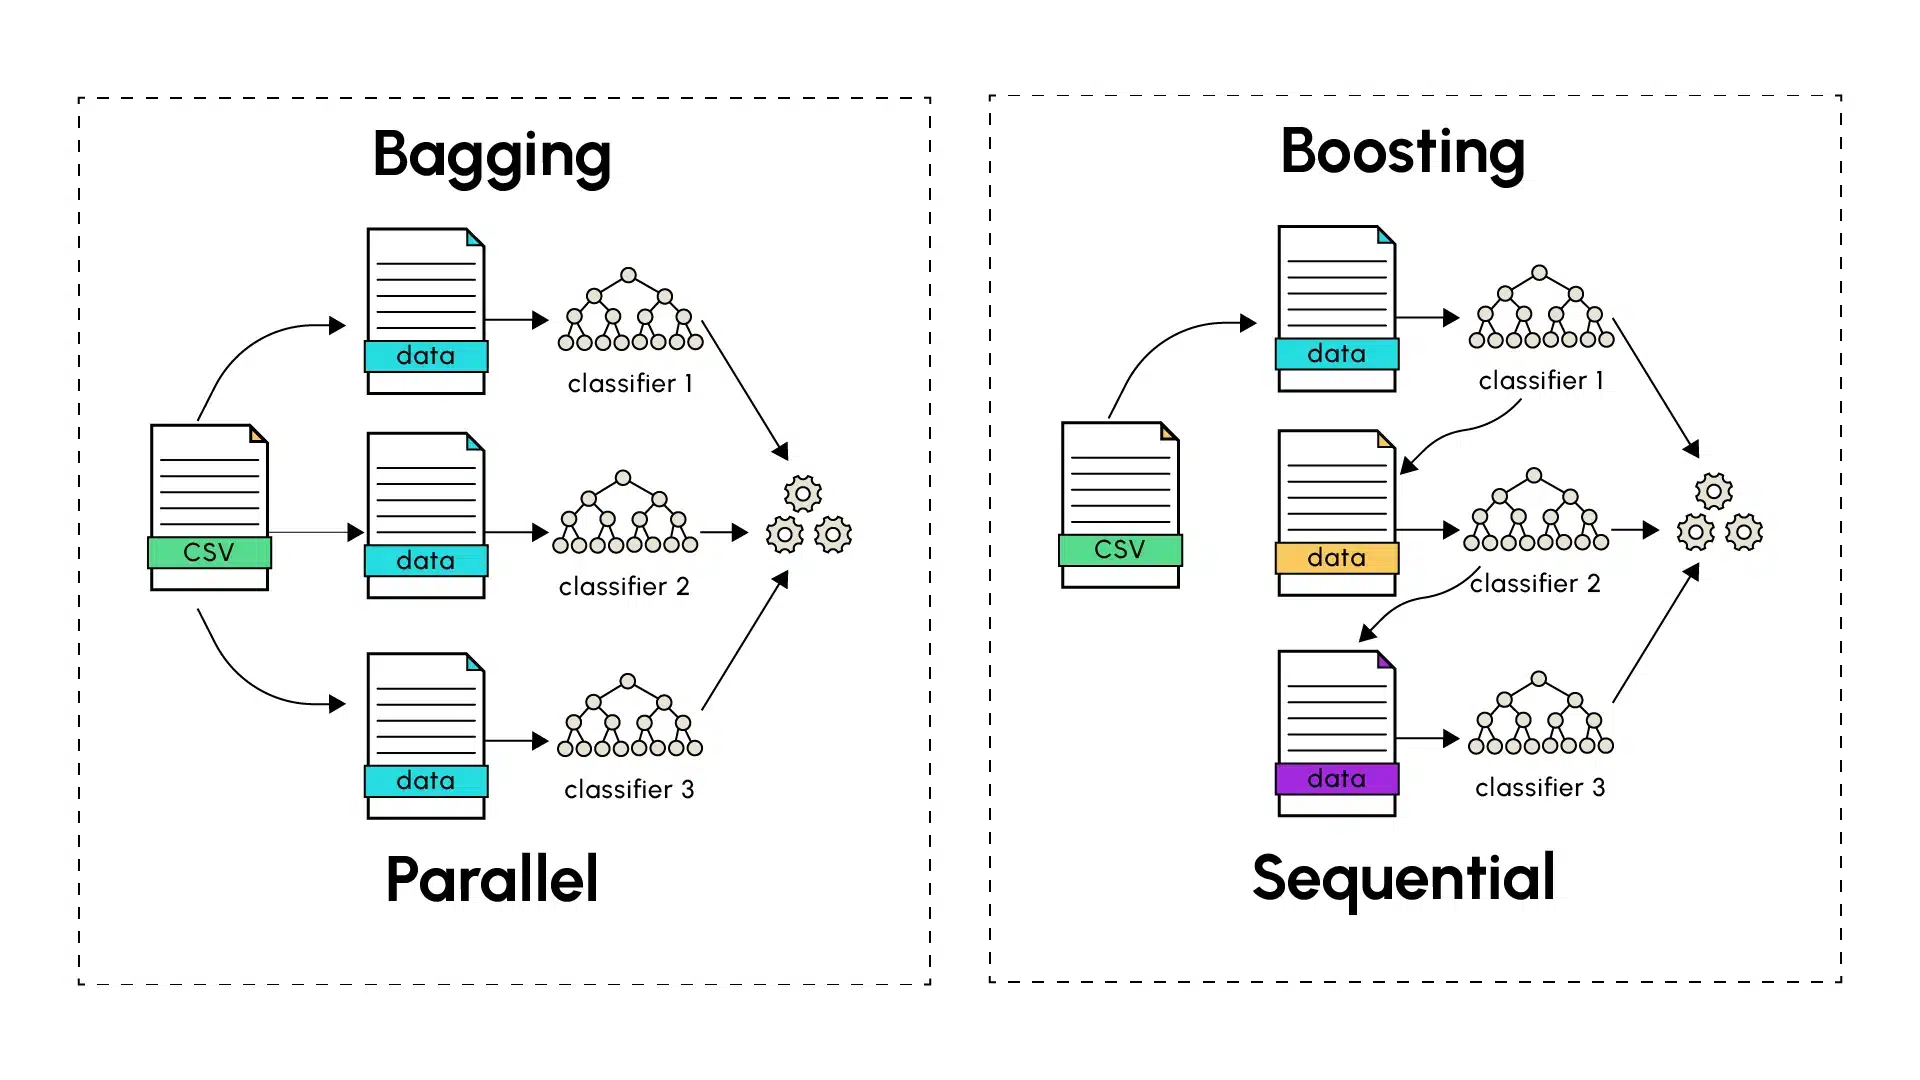

# Random Forest

## 1. Introducción

El **Random Forest** es un método de aprendizaje supervisado basado en **ensambles de árboles de decisión**.
Fue propuesto por **Leo Breiman (2001)** como una mejora del método **bagging**, introduciendo aleatoriedad adicional en la selección de variables.

La idea central consiste en construir muchos árboles de decisión y combinar sus predicciones para obtener un modelo más robusto y con menor varianza.

Para clasificación, la predicción final se obtiene por **votación mayoritaria**, mientras que para regresión se usa el **promedio de las predicciones**.

---

## 2. Idea del Método

Sea un conjunto de datos

[
\mathcal{D} = {(x_i,y_i)}_{i=1}^{n}
]

donde

* (x_i \in \mathbb{R}^p) vector de variables explicativas
* (y_i) variable respuesta.

Random Forest construye (B) árboles de decisión:

[
T_1(x),T_2(x),\dots,T_B(x)
]

y el predictor final es

### Clasificación

[
\hat{y} = \text{modo}{T_b(x)}_{b=1}^{B}
]

### Regresión

[
\hat{f}(x) = \frac{1}{B}\sum_{b=1}^{B} T_b(x)
]

---

## 3. Bagging (Bootstrap Aggregating)

Random Forest se basa en el principio de **bagging**.

Para cada árbol:

1. Se genera una muestra bootstrap de tamaño (n).
2. Se entrena un árbol de decisión usando esa muestra.
3. Se combinan los resultados.

Formalmente, cada conjunto bootstrap es

[
\mathcal{D}*b = {(x_i^*,y_i^*)}*{i=1}^{n}
]

donde las observaciones se seleccionan **con reemplazo**.

El estimador bagging es

[
\hat{f}*{bag}(x)=\frac{1}{B}\sum*{b=1}^{B}T_b(x)
]

---

## 4. Selección Aleatoria de Variables

La innovación principal de Random Forest es que **en cada nodo del árbol** solo se considera un subconjunto aleatorio de variables.

Si existen (p) variables:

* se selecciona aleatoriamente un subconjunto de tamaño (m)
* se busca la mejor división solo entre esas variables.

Usualmente:

* Clasificación:

[
m=\sqrt{p}
]

* Regresión:

[
m=\frac{p}{3}
]

Esto reduce la correlación entre árboles y mejora el desempeño del ensamble.

---

## 5. Algoritmo Random Forest

El procedimiento es el siguiente:

1. Para (b = 1,\dots,B):

   a) Generar muestra bootstrap
   b) Construir un árbol de clasificación sin poda
   c) En cada nodo seleccionar (m) variables aleatoriamente
   d) Elegir la mejor división entre esas variables

2. Repetir hasta obtener (B) árboles.

3. Combinar predicciones.

---

## 6. Error Out-of-Bag (OOB)

Debido al muestreo bootstrap, aproximadamente **un tercio de los datos no se utiliza** en cada árbol.

Estas observaciones se llaman **Out-of-Bag (OOB)**.

El error OOB se calcula como

[
OOB = \frac{1}{n}\sum_{i=1}^{n} I(y_i \neq \hat{y}_{OOB,i})
]

donde (\hat{y}_{OOB,i}) es la predicción usando solo los árboles donde la observación (i) no fue usada en el entrenamiento.

Este error funciona como una **validación cruzada interna**.

---

## 7. Importancia de Variables

Random Forest permite medir la **importancia de las variables**.

Dos medidas comunes son:

### Disminución del índice de Gini

[
VI_j = \sum_{t} \Delta Gini_t
]

donde se suma la reducción de impureza en todos los nodos donde aparece la variable.

### Permutation Importance

Se mide el aumento del error cuando se permuta la variable (X_j).

[
VI_j = Err_{perm,j} - Err_{original}
]

---

## 8. Ventajas

* Reduce la **varianza** de los árboles.
* Maneja **grandes conjuntos de variables**.
* Permite estimar **importancia de variables**.
* Generalmente tiene **alto poder predictivo**.

---

## 9. Desventajas

* Menor interpretabilidad que un árbol simple.
* Puede ser computacionalmente costoso.
* Los modelos grandes requieren más memoria.

---

## 10. Aplicaciones

Random Forest es ampliamente utilizado en:

* clasificación médica
* reconocimiento de imágenes
* bioinformática
* sistemas de recomendación
* análisis financiero

---

## 11. Conclusión

Random Forest es uno de los métodos de aprendizaje automático más robustos y utilizados. Al combinar múltiples árboles con técnicas de aleatorización, logra reducir la varianza y mejorar significativamente la capacidad predictiva frente a un solo árbol de decisión.


In [13]:

# ==========================================
# RANDOM FOREST CON PYSPARK - DATASET IRIS
# ==========================================

# instalar pyspark si es necesario
# !pip install pyspark

from pyspark.sql import SparkSession
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

import pandas as pd
from sklearn.datasets import load_iris

# ------------------------------------------
# 1 Crear sesión Spark
# ------------------------------------------

spark = SparkSession.builder \
    .appName("RandomForest_Iris") \
    .getOrCreate()

# ------------------------------------------
# 2 Cargar dataset Iris
# ------------------------------------------

iris = load_iris()

df = pd.DataFrame(
    iris.data,
    columns=[
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width"
    ]
)

df["species"] = iris.target

spark_df = spark.createDataFrame(df)

spark_df.show(5)

# ------------------------------------------
# 3 Crear vector de características
# ------------------------------------------

assembler = VectorAssembler(
    inputCols=[
        "sepal_length",
        "sepal_width",
        "petal_length",
        "petal_width"
    ],
    outputCol="features"
)

# ------------------------------------------
# 4 Modelo Random Forest
# ------------------------------------------

rf = RandomForestClassifier(
    labelCol="species",
    featuresCol="features",
    numTrees=100,
    maxDepth=5,
    seed=123
)

pipeline = Pipeline(stages=[assembler, rf])

# ------------------------------------------
# 5 División entrenamiento / prueba
# ------------------------------------------

train, test = spark_df.randomSplit([0.7, 0.3], seed=42)

# ------------------------------------------
# 6 Entrenar modelo
# ------------------------------------------

model = pipeline.fit(train)

# ------------------------------------------
# 7 Predicciones
# ------------------------------------------

predictions = model.transform(test)

predictions.select(
    "species",
    "prediction",
    "probability"
).show(10)

# ------------------------------------------
# 8 Evaluación del modelo
# ------------------------------------------

evaluator = MulticlassClassificationEvaluator(
    labelCol="species",
    predictionCol="prediction",
    metricName="accuracy"
)

accuracy = evaluator.evaluate(predictions)

print("Accuracy:", accuracy)

# ------------------------------------------
# 9 Matriz de confusión
# ------------------------------------------

pred_pd = predictions.select("species", "prediction").toPandas()

confusion_matrix = pd.crosstab(
    pred_pd["species"],
    pred_pd["prediction"],
    rownames=["Actual"],
    colnames=["Predicted"]
)

print(confusion_matrix)

# ------------------------------------------
# 10 Importancia de variables
# ------------------------------------------

rf_model = model.stages[-1]

importances = rf_model.featureImportances

features = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]

importance_df = pd.DataFrame({
    "feature": features,
    "importance": importances.toArray()
})

print(importance_df.sort_values(by="importance", ascending=False))



+------------+-----------+------------+-----------+-------+
|sepal_length|sepal_width|petal_length|petal_width|species|
+------------+-----------+------------+-----------+-------+
|         5.1|        3.5|         1.4|        0.2|      0|
|         4.9|        3.0|         1.4|        0.2|      0|
|         4.7|        3.2|         1.3|        0.2|      0|
|         4.6|        3.1|         1.5|        0.2|      0|
|         5.0|        3.6|         1.4|        0.2|      0|
+------------+-----------+------------+-----------+-------+
only showing top 5 rows
+-------+----------+--------------------+
|species|prediction|         probability|
+-------+----------+--------------------+
|      0|       0.0|       [1.0,0.0,0.0]|
|      0|       0.0|       [1.0,0.0,0.0]|
|      0|       0.0|       [1.0,0.0,0.0]|
|      0|       0.0|       [1.0,0.0,0.0]|
|      0|       0.0|       [1.0,0.0,0.0]|
|      0|       0.0|       [1.0,0.0,0.0]|
|      0|       0.0|[0.8,0.1991836734...|
|      0|       

# Bagging (Bootstrap Aggregating)

## 1. Introducción

El **Bagging (Bootstrap Aggregating)** es un método de **ensamble** propuesto por **Leo Breiman (1996)** cuyo objetivo es mejorar la estabilidad y precisión de los modelos de aprendizaje automático.

La idea principal consiste en generar múltiples versiones de un predictor utilizando muestras **bootstrap** del conjunto de datos original y luego combinar sus predicciones.

Este método es especialmente efectivo para modelos con **alta varianza**, como los **árboles de decisión**.

---

## 2. Conjunto de Datos

Sea el conjunto de entrenamiento

[
\mathcal{D} = {(x_1,y_1),(x_2,y_2),\dots,(x_n,y_n)}
]

donde

* (x_i \in \mathbb{R}^p) representa el vector de características
* (y_i) es la variable respuesta.

---

## 3. Muestreo Bootstrap

El método bagging genera (B) muestras bootstrap:

[
\mathcal{D}_1,\mathcal{D}_2,\dots,\mathcal{D}_B
]

Cada muestra se obtiene **con reemplazo** a partir de (\mathcal{D}).

Formalmente

[
\mathcal{D}_b = {(x_1^*,y_1^*),\dots,(x_n^*,y_n^*)}
]

donde cada observación se selecciona aleatoriamente del conjunto original.

En promedio, cada muestra bootstrap contiene aproximadamente

[
63.2%
]

de observaciones únicas del conjunto original.

---

## 4. Construcción de Modelos

Para cada muestra bootstrap se entrena un modelo:

[
\hat{f}_1(x),\hat{f}_2(x),\dots,\hat{f}_B(x)
]

Cada modelo se ajusta de manera independiente.

---

## 5. Agregación de Predicciones

La predicción final se obtiene combinando los predictores individuales.

### Regresión

[
\hat{f}*{bag}(x) =
\frac{1}{B}
\sum*{b=1}^{B}
\hat{f}_b(x)
]

Es decir, el promedio de las predicciones.

---

### Clasificación

[
\hat{y} =
\text{modo}
{\hat{f}_1(x),\hat{f}_2(x),\dots,\hat{f}_B(x)}
]

Se utiliza **votación mayoritaria**.

---

## 6. Reducción de Varianza

Una de las principales ventajas del bagging es la reducción de la varianza del modelo.

Si cada predictor tiene varianza ( \sigma^2 ) y correlación ( \rho ), la varianza del promedio es aproximadamente

[
Var(\hat{f}_{bag}) =
\rho \sigma^2 +
\frac{1-\rho}{B}\sigma^2
]

A medida que (B) aumenta, la varianza disminuye.

---

## 7. Error Out-of-Bag (OOB)

Debido al muestreo bootstrap, algunas observaciones no se utilizan en la construcción de cada modelo.

Estas observaciones se llaman **Out-of-Bag (OOB)**.

El error OOB se calcula como

[
OOB =
\frac{1}{n}
\sum_{i=1}^{n}
I(y_i \neq \hat{y}_{OOB,i})
]

donde (\hat{y}_{OOB,i}) es la predicción usando solo los modelos donde la observación (i) no fue utilizada.

Este error funciona como una forma de **validación cruzada interna**.

---

## 8. Ventajas del Bagging

* Reduce la **varianza del modelo**
* Mejora la **estabilidad de los predictores**
* Disminuye el **sobreajuste**
* Fácil de implementar

---

## 9. Desventajas

* Incrementa el costo computacional
* No reduce el **sesgo del modelo**
* Puede ser difícil interpretar el ensamble completo

---

## 10. Relación con Random Forest

El método **Random Forest** es una extensión del bagging en la cual:

* Se utilizan **árboles de decisión**
* En cada nodo se selecciona un **subconjunto aleatorio de variables**

Esto introduce más aleatoriedad y reduce la correlación entre los árboles.

---


El bagging es uno de los métodos fundamentales de **aprendizaje por ensamble**.
Su capacidad para reducir la varianza lo convierte en una herramienta poderosa para mejorar el desempeño de modelos inestables como los árboles de decisión. Además, constituye la base de métodos más avanzados como **Random Forest**.


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Reporte de Clasificación:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



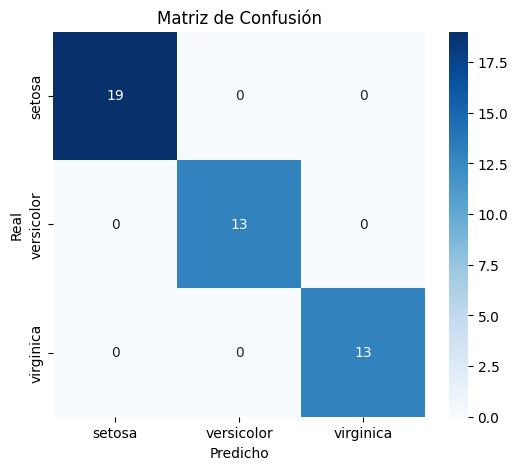


Importancia de Variables:

            Variable  Importancia
2  petal length (cm)     0.954096
3   petal width (cm)     0.045904
1   sepal width (cm)     0.000000
0  sepal length (cm)     0.000000


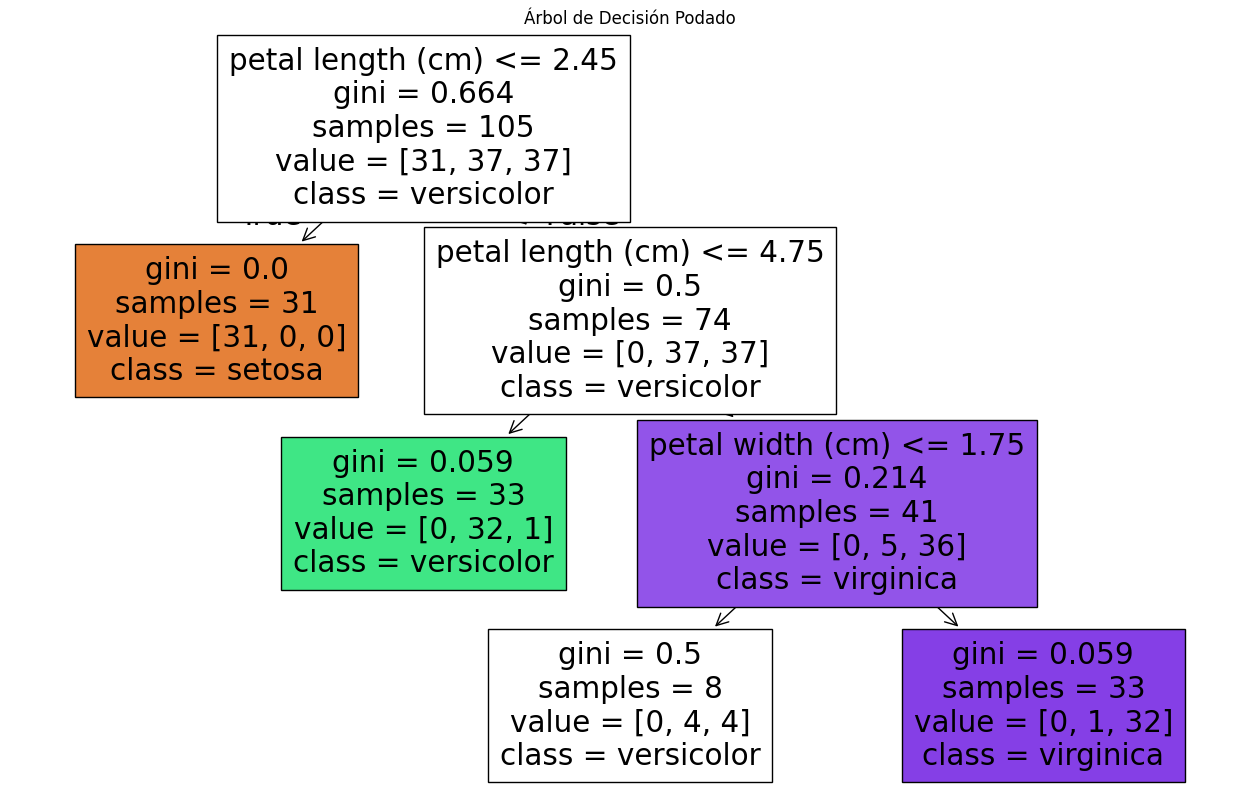

In [14]:

# ======================================
# BAGGING CON ÁRBOLES - DATASET IRIS
# ======================================

# instalar librerías si hace falta
# !pip install scikit-learn matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from sklearn.tree import plot_tree

# ======================================
# 1 Cargar dataset
# ======================================

iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
class_names = iris.target_names

# ======================================
# 2 División entrenamiento prueba
# ======================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# ======================================
# 3 PODA DEL ÁRBOL (Cost Complexity)
# ======================================

tree = DecisionTreeClassifier(random_state=42)

path = tree.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas

trees = []

for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=42,
        ccp_alpha=alpha
    )
    clf.fit(X_train, y_train)
    trees.append(clf)

# escoger árbol podado intermedio
pruned_tree = trees[len(trees)//2]

# ======================================
# 4 MODELO BAGGING
# ======================================

bagging = BaggingClassifier(
    estimator=pruned_tree,
    n_estimators=100,
    max_samples=0.8,
    bootstrap=True,
    random_state=42
)

bagging.fit(X_train, y_train)

# ======================================
# 5 PREDICCIONES
# ======================================

y_pred = bagging.predict(X_test)

# ======================================
# 6 MÉTRICAS
# ======================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nReporte de Clasificación:\n")
print(classification_report(y_test, y_pred))

# ======================================
# 7 MATRIZ DE CONFUSIÓN
# ======================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

# ======================================
# 8 IMPORTANCIA DE VARIABLES
# ======================================

importances = pruned_tree.feature_importances_

importance_df = pd.DataFrame({
    "Variable": feature_names,
    "Importancia": importances
}).sort_values(by="Importancia", ascending=False)

print("\nImportancia de Variables:\n")
print(importance_df)

# ======================================
# 9 GRÁFICO DEL ÁRBOL
# ======================================

plt.figure(figsize=(16,10))

plot_tree(
    pruned_tree,
    feature_names=feature_names,
    class_names=class_names,
    filled=True
)

plt.title("Árbol de Decisión Podado")
plt.show()


# Boosting

## 1. Introducción

El **Boosting** es una técnica de **aprendizaje por ensamble** que combina múltiples modelos débiles (*weak learners*) para formar un predictor fuerte (*strong learner*).

A diferencia de **bagging**, donde los modelos se entrenan de forma independiente, en boosting los modelos se entrenan **secuencialmente**, de modo que cada nuevo modelo intenta corregir los errores cometidos por los modelos anteriores.

Los algoritmos de boosting más conocidos son:

* **AdaBoost**
* **Gradient Boosting**
* **XGBoost**
* **LightGBM**

---

## 2. Idea del Método

Sea un conjunto de entrenamiento

[
\mathcal{D} = {(x_1,y_1),(x_2,y_2),\dots,(x_n,y_n)}
]

donde

* (x_i \in \mathbb{R}^p) son las variables explicativas
* (y_i) es la variable respuesta.

Boosting construye un modelo aditivo

[
F(x) = \sum_{m=1}^{M} \alpha_m h_m(x)
]

donde

* (h_m(x)) es un **modelo débil**
* (\alpha_m) es el peso del modelo
* (M) número total de iteraciones.

---

## 3. AdaBoost

Uno de los algoritmos más conocidos es **AdaBoost (Adaptive Boosting)**.

Inicialmente se asignan pesos iguales a todas las observaciones

[
w_i = \frac{1}{n}
]

Luego se entrena un clasificador débil (h_m(x)).

El error ponderado del modelo es

[
\epsilon_m =
\sum_{i=1}^{n}
w_i I(y_i \neq h_m(x_i))
]

---

### Peso del Clasificador

El peso del clasificador es

[
\alpha_m =
\frac{1}{2}
\ln
\left(
\frac{1-\epsilon_m}{\epsilon_m}
\right)
]

---

### Actualización de Pesos

Los pesos de las observaciones se actualizan como

[
w_i \leftarrow
w_i
\exp(-\alpha_m y_i h_m(x_i))
]

Posteriormente se normalizan para que

[
\sum_{i=1}^{n} w_i = 1
]

---

## 4. Predictor Final

La predicción final se obtiene mediante

[
F(x) =
\sum_{m=1}^{M}
\alpha_m h_m(x)
]

y la clasificación final es

[
\hat{y} =
\text{sign}(F(x))
]

---

## 5. Gradient Boosting

El **Gradient Boosting** generaliza el boosting como un problema de optimización.

El modelo se construye minimizando una función de pérdida

[
L(y,F(x))
]

El modelo aditivo se construye como

[
F_m(x) =
F_{m-1}(x)
+
\nu h_m(x)
]

donde

* (h_m(x)) aproxima el **gradiente negativo**
* (\nu) es el **learning rate**.

---

## 6. Algoritmo Gradient Boosting

1. Inicializar

[
F_0(x) =
\arg\min_c
\sum_{i=1}^{n}
L(y_i,c)
]

2. Para (m = 1,\dots,M)

Calcular residuos

[
r_{im} =
--------

\left[
\frac{\partial
L(y_i,F(x_i))}
{\partial F(x_i)}
\right]
]

3. Ajustar un árbol a los residuos

[
h_m(x)
]

4. Actualizar el modelo

[
F_m(x) =
F_{m-1}(x)
+
\nu h_m(x)
]

---

## 7. Ventajas

* Alta capacidad predictiva
* Maneja relaciones complejas
* Reduce el sesgo del modelo
* Muy utilizado en competencias de *machine learning*

---

## 8. Desventajas

* Sensible a ruido
* Puede sobreajustar si no se regulariza
* Mayor costo computacional

---

## 9. Comparación con Bagging

| Método        | Idea                                       |
| ------------- | ------------------------------------------ |
| Bagging       | Modelos independientes                     |
| Random Forest | Bagging + selección aleatoria de variables |
| Boosting      | Modelos secuenciales corrigiendo errores   |

---


Boosting es una de las técnicas más poderosas en aprendizaje automático. Al construir modelos de manera secuencial y enfocarse en las observaciones difíciles de clasificar, logra mejorar significativamente el desempeño predictivo frente a modelos individuales.


Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0

Reporte de Clasificación

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        13
           2       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



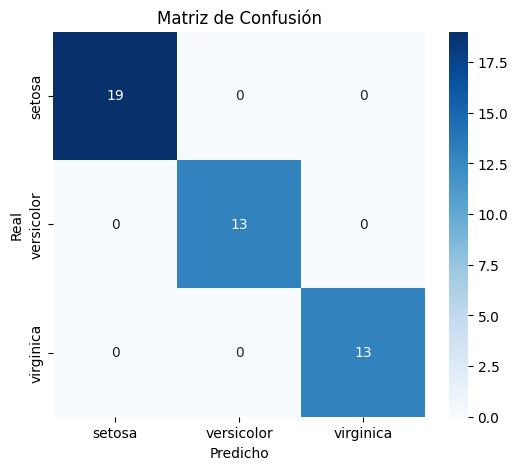


Importancia de Variables

            Variable  Importancia
2  petal length (cm)     0.595202
3   petal width (cm)     0.383604
1   sepal width (cm)     0.017775
0  sepal length (cm)     0.003420


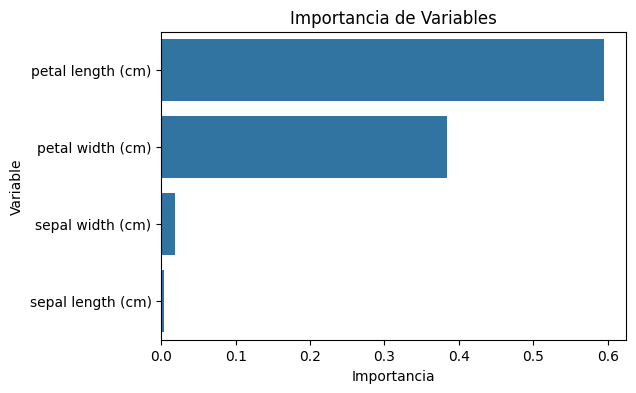

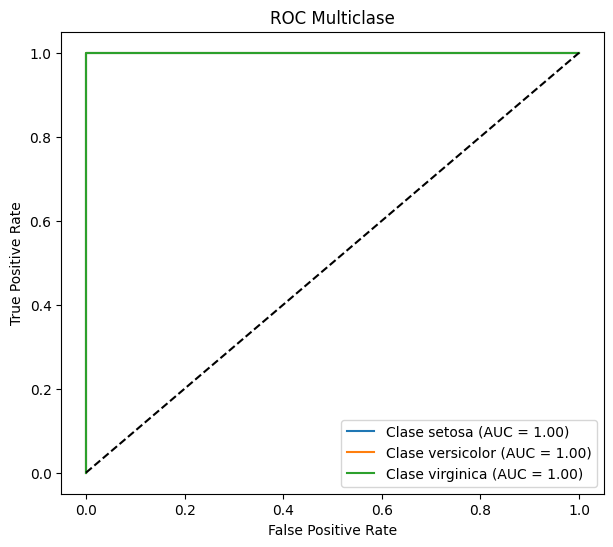

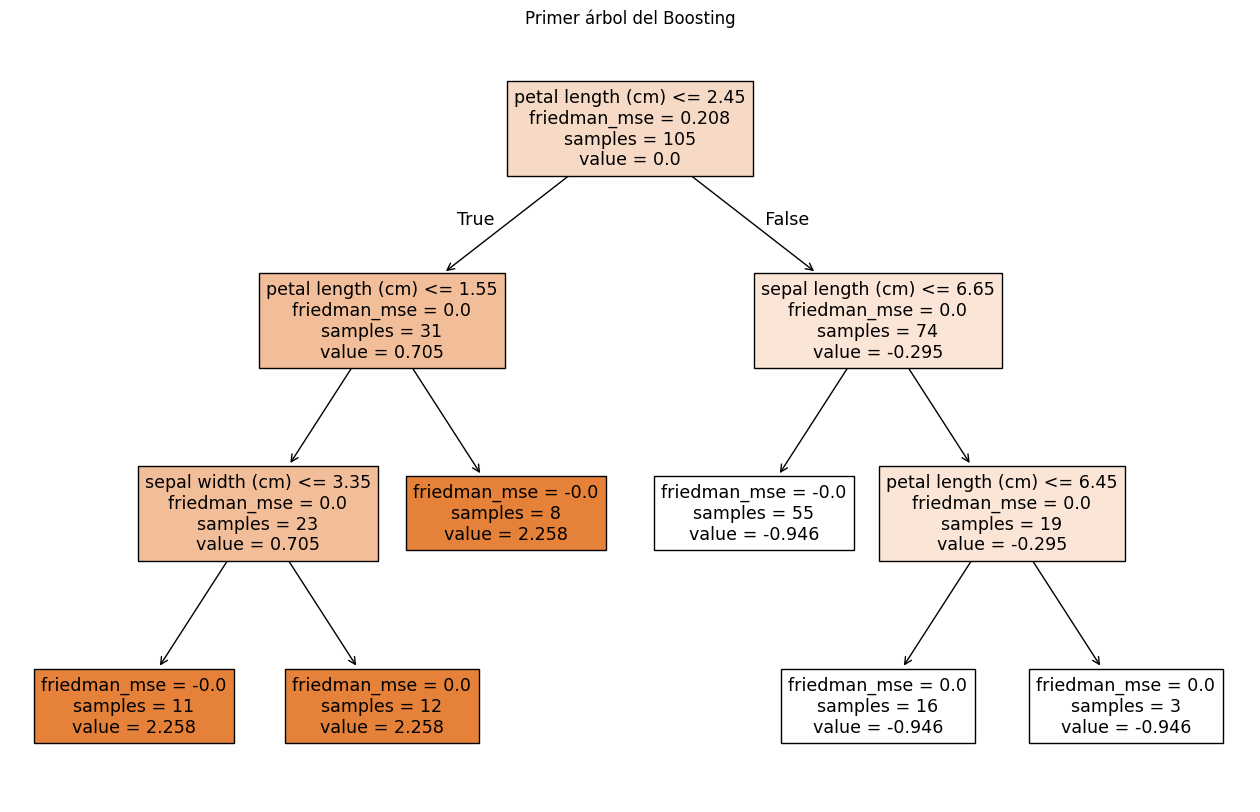

In [15]:

# ======================================
# BOOSTING (GRADIENT BOOSTING) - IRIS
# ======================================

# !pip install scikit-learn seaborn matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize
from sklearn.tree import plot_tree

# ======================================
# 1 Cargar dataset
# ======================================

iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
class_names = iris.target_names

# ======================================
# 2 Train / Test
# ======================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# ======================================
# 3 Modelo Boosting
# ======================================

model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

model.fit(X_train, y_train)

# ======================================
# 4 Predicciones
# ======================================

y_pred = model.predict(X_test)

# ======================================
# 5 MÉTRICAS
# ======================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nReporte de Clasificación\n")
print(classification_report(y_test, y_pred))

# ======================================
# 6 MATRIZ DE CONFUSIÓN
# ======================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

# ======================================
# 7 IMPORTANCIA DE VARIABLES
# ======================================

importances = model.feature_importances_

importance_df = pd.DataFrame({
    "Variable": feature_names,
    "Importancia": importances
}).sort_values(by="Importancia", ascending=False)

print("\nImportancia de Variables\n")
print(importance_df)

plt.figure(figsize=(6,4))

sns.barplot(
    x="Importancia",
    y="Variable",
    data=importance_df
)

plt.title("Importancia de Variables")
plt.show()

# ======================================
# 8 CURVA ROC MULTICLASE
# ======================================

y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_score = model.predict_proba(X_test)

n_classes = y_test_bin.shape[1]

plt.figure(figsize=(7,6))

for i in range(n_classes):

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"Clase {class_names[i]} (AUC = {roc_auc:.2f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Multiclase")
plt.legend()
plt.show()

# ======================================
# 9 VISUALIZAR UNO DE LOS ÁRBOLES
# ======================================

plt.figure(figsize=(16,10))

plot_tree(
    model.estimators_[0,0],
    feature_names=feature_names,
    filled=True
)

plt.title("Primer árbol del Boosting")
plt.show()


# XGBoost (Extreme Gradient Boosting)

## 1. Introducción

**XGBoost (Extreme Gradient Boosting)** es un algoritmo de aprendizaje supervisado basado en el método de **gradient boosting** que utiliza **árboles de decisión** como modelos base.

Fue desarrollado por **Tianqi Chen (2016)** y se caracteriza por:

* alta eficiencia computacional
* regularización explícita
* paralelización
* manejo eficiente de grandes volúmenes de datos.

El modelo pertenece a la familia de **modelos aditivos de árboles**.

---

# 2. Modelo Aditivo

Sea un conjunto de datos

[
\mathcal{D} = {(x_i,y_i)}_{i=1}^{n}
]

donde

[
x_i \in \mathbb{R}^p
]

y (y_i) es la variable respuesta.

XGBoost modela la predicción como una suma de árboles:

[
\hat{y}*i =
\sum*{k=1}^{K}
f_k(x_i)
]

donde

* (f_k) es un árbol de decisión
* (K) es el número total de árboles.

Cada función pertenece al espacio

[
f_k \in \mathcal{F}
]

donde

[
\mathcal{F} =
{f(x) = w_{q(x)}}
]

con

* (q(x)) estructura del árbol
* (w) peso asociado a cada hoja.

---

# 3. Función Objetivo

XGBoost minimiza la siguiente función objetivo:

[
\mathcal{L} =
\sum_{i=1}^{n}
l(y_i,\hat{y}*i)
+
\sum*{k=1}^{K}
\Omega(f_k)
]

donde

* (l(\cdot)) función de pérdida
* (\Omega(\cdot)) término de regularización.

---

# 4. Regularización

La penalización para cada árbol es

[
\Omega(f) =
\gamma T +
\frac{1}{2}
\lambda
\sum_{j=1}^{T}
w_j^2
]

donde

* (T) número de hojas
* (w_j) peso de la hoja
* (\gamma) penalización por complejidad
* (\lambda) regularización L2.

Esto controla el **sobreajuste del modelo**.

---

# 5. Optimización Secuencial

El modelo se construye iterativamente.

En la iteración (t):

[
\hat{y}_i^{(t)} =
\hat{y}_i^{(t-1)} +
f_t(x_i)
]

La función objetivo es

[
\mathcal{L}^{(t)} =
\sum_{i=1}^{n}
l(y_i,\hat{y}_i^{(t-1)} + f_t(x_i))
+
\Omega(f_t)
]

---

# 6. Aproximación de Segundo Orden

XGBoost utiliza expansión de Taylor de segundo orden.

[
l(y_i,\hat{y}_i^{(t)})
\approx
l(y_i,\hat{y}_i^{(t-1)})
+
g_i f_t(x_i)
+
\frac{1}{2} h_i f_t(x_i)^2
]

donde

[
g_i =
\frac{\partial l(y_i,\hat{y}_i)}{\partial \hat{y}_i}
]

[
h_i =
\frac{\partial^2 l(y_i,\hat{y}_i)}{\partial \hat{y}_i^2}
]

representan:

* gradiente
* hessiano.

---

# 7. Función Objetivo Aproximada

Sustituyendo:

[
\tilde{\mathcal{L}}^{(t)}
=========================

\sum_{i=1}^{n}
\left(
g_i f_t(x_i)
+
\frac{1}{2}
h_i f_t(x_i)^2
\right)
+
\Omega(f_t)
]

---

# 8. Representación por Hojas

Si una hoja contiene el conjunto de observaciones (I_j), entonces

[
\tilde{\mathcal{L}}^{(t)}
=========================

\sum_{j=1}^{T}
\left[
G_j w_j +
\frac{1}{2}
(H_j+\lambda) w_j^2
\right]
+
\gamma T
]

donde

[
G_j =
\sum_{i \in I_j} g_i
]

[
H_j =
\sum_{i \in I_j} h_i
]

---

# 9. Peso Óptimo de las Hojas

El peso óptimo se obtiene derivando:

[
w_j^* =
-------

\frac{G_j}{H_j+\lambda}
]

---

# 10. Valor de la Función Objetivo

Sustituyendo el valor óptimo:

[
\tilde{\mathcal{L}}^{(t)}
=========================

*

\frac{1}{2}
\sum_{j=1}^{T}
\frac{G_j^2}{H_j+\lambda}
+
\gamma T
]

---

# 11. Ganancia de División

Para decidir una división del árbol se calcula la ganancia:

[
Gain =
\frac{1}{2}
\left(
\frac{G_L^2}{H_L+\lambda}
+
\frac{G_R^2}{H_R+\lambda}
-------------------------

\frac{(G_L+G_R)^2}{H_L+H_R+\lambda}
\right)
-------

\gamma
]

donde

* (G_L,H_L) corresponden al nodo izquierdo
* (G_R,H_R) corresponden al nodo derecho.

La división se realiza solo si **Gain > 0**.

---

# 12. Ventajas de XGBoost

* regularización explícita
* manejo eficiente de datos faltantes
* paralelización
* alto rendimiento predictivo
* control del sobreajuste.

---

XGBoost es una extensión altamente optimizada del **gradient boosting** que combina:

* modelos aditivos de árboles
* optimización de segundo orden
* regularización estructural.

Estas características lo convierten en uno de los algoritmos más poderosos en problemas de **machine learning supervisado**.



# ======================================
# XGBOOST - DATASET IRIS
# ======================================

# instalar librerías si hace falta
# !pip install xgboost scikit-learn seaborn matplotlib

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    auc
)

from sklearn.preprocessing import label_binarize

import xgboost as xgb

# ======================================
# 1 Cargar dataset
# ======================================

iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
class_names = iris.target_names

# ======================================
# 2 División Train/Test
# ======================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# ======================================
# 3 MODELO XGBOOST
# ======================================

model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=3,
    random_state=42
)

model.fit(X_train, y_train)

# ======================================
# 4 PREDICCIONES
# ======================================

y_pred = model.predict(X_test)

# ======================================
# 5 MÉTRICAS
# ======================================

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted")
recall = recall_score(y_test, y_pred, average="weighted")
f1 = f1_score(y_test, y_pred, average="weighted")

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

print("\nReporte de Clasificación\n")
print(classification_report(y_test, y_pred))

# ======================================
# 6 MATRIZ DE CONFUSIÓN
# ======================================

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicho")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.show()

# ======================================
# 7 IMPORTANCIA DE VARIABLES
# ======================================

importance_df = pd.DataFrame({
    "Variable": feature_names,
    "Importancia": model.feature_importances_
}).sort_values(by="Importancia", ascending=False)

print("\nImportancia de Variables\n")
print(importance_df)

plt.figure(figsize=(6,4))

sns.barplot(
    x="Importancia",
    y="Variable",
    data=importance_df
)

plt.title("Importancia de Variables - XGBoost")
plt.show()

# ======================================
# 8 CURVA ROC MULTICLASE
# ======================================

y_test_bin = label_binarize(y_test, classes=[0,1,2])
y_score = model.predict_proba(X_test)

n_classes = y_test_bin.shape[1]

plt.figure(figsize=(7,6))

for i in range(n_classes):

    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"Clase {class_names[i]} (AUC = {roc_auc:.2f})"
    )

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Multiclase - XGBoost")
plt.legend()
plt.show()

# ======================================
# 9 VISUALIZAR ÁRBOL DE XGBOOST
# ======================================

plt.figure(figsize=(18,10))

xgb.plot_tree(model, num_trees=0)

plt.title("Primer Árbol de XGBoost")
plt.show()



TABLA COMPARATIVA

          Modelo  Accuracy  Precision  Recall   F1
0  Decision Tree       1.0        1.0     1.0  1.0
1        Bagging       1.0        1.0     1.0  1.0
2  Random Forest       1.0        1.0     1.0  1.0
3        XGBoost       1.0        1.0     1.0  1.0


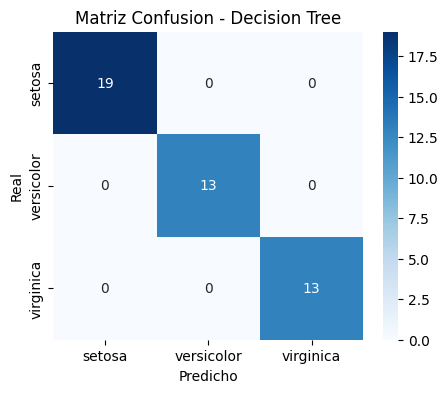

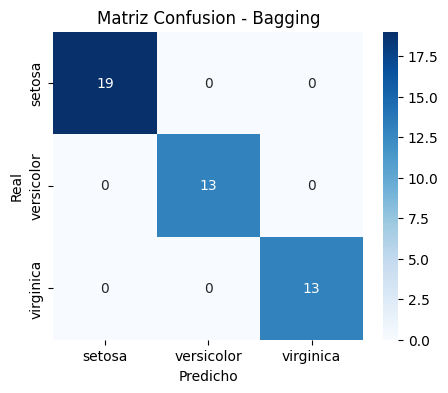

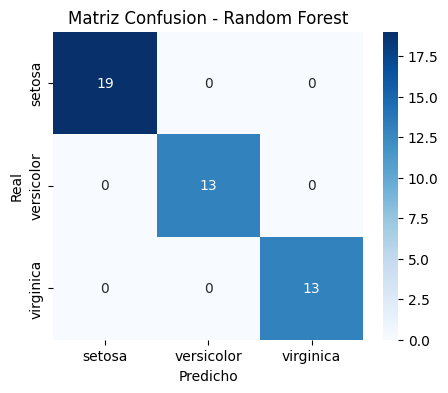

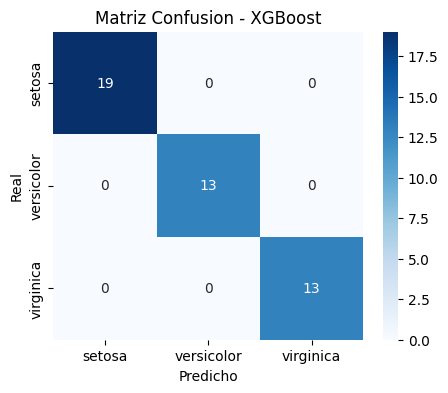

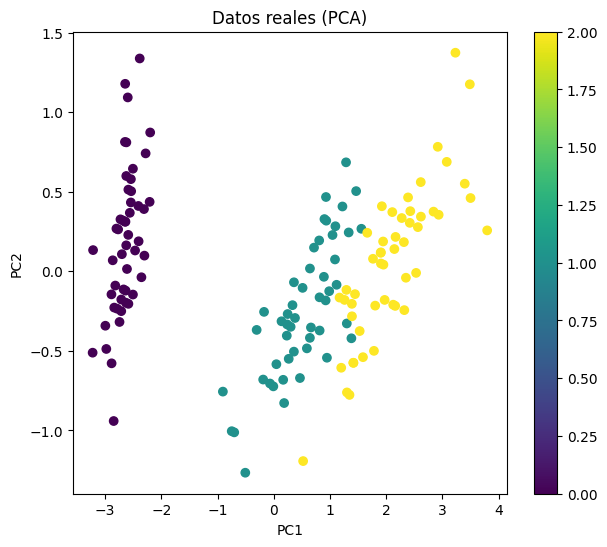

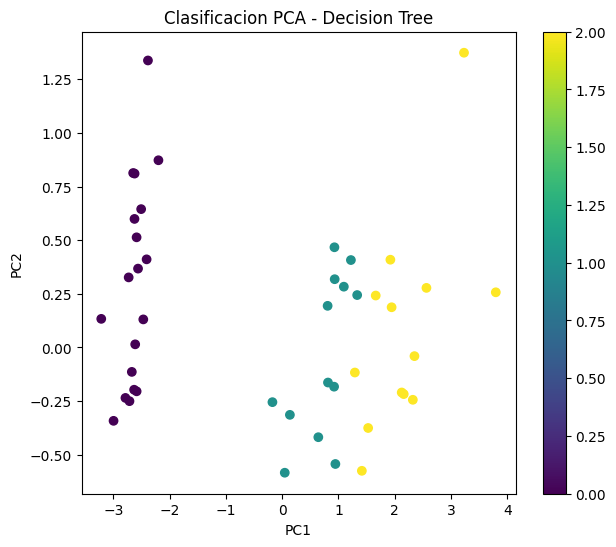

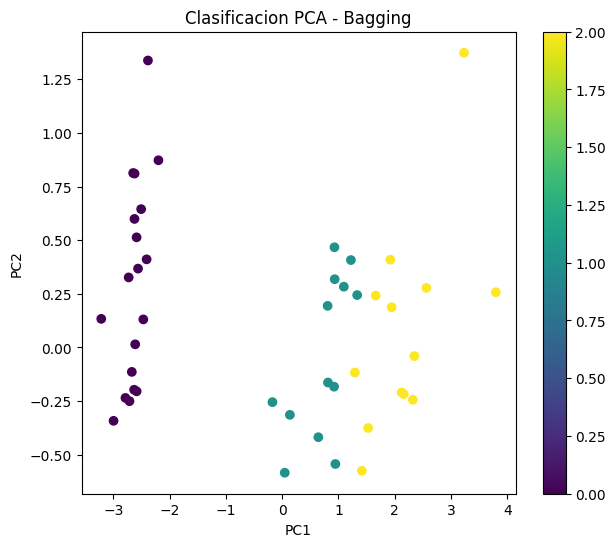

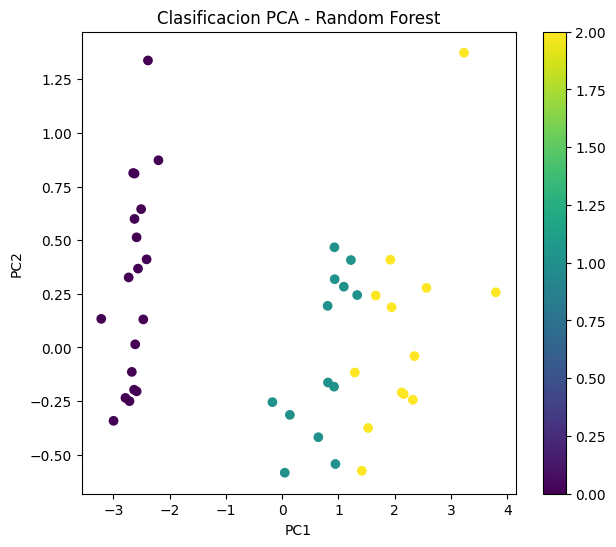

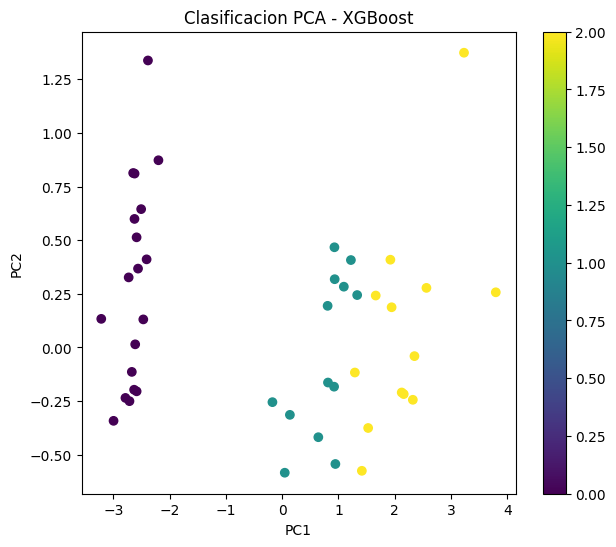

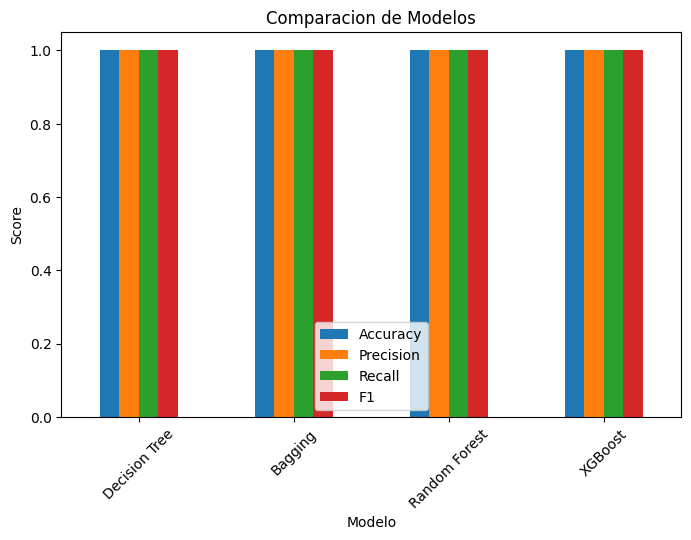


MEJOR MODELO

Modelo       Decision Tree
Accuracy               1.0
Precision              1.0
Recall                 1.0
F1                     1.0
Name: 0, dtype: object


In [16]:

# ==========================================
# COMPARACION DE MODELOS - IRIS
# Decision Tree vs Bagging vs Random Forest vs XGBoost
# ==========================================

# !pip install xgboost seaborn scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

# ==========================================
# 1 CARGAR DATOS
# ==========================================

iris = load_iris()

X = iris.data
y = iris.target

feature_names = iris.feature_names
class_names = iris.target_names

# ==========================================
# 2 TRAIN TEST SPLIT
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# ==========================================
# 3 DEFINIR MODELOS
# ==========================================

models = {

"Decision Tree":
DecisionTreeClassifier(max_depth=4),

"Bagging":
BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100
),

"Random Forest":
RandomForestClassifier(
    n_estimators=100,
    max_depth=4
),

"XGBoost":
xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    objective="multi:softprob",
    num_class=3
)
}

# ==========================================
# 4 ENTRENAR Y EVALUAR
# ==========================================

results = []

predictions_dict = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    predictions_dict[name] = y_pred

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted")
    rec = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    results.append([name, acc, prec, rec, f1])

# ==========================================
# 5 TABLA COMPARATIVA
# ==========================================

results_df = pd.DataFrame(
    results,
    columns=["Modelo","Accuracy","Precision","Recall","F1"]
)

print("\nTABLA COMPARATIVA\n")
print(results_df)

# ==========================================
# 6 MATRICES DE CONFUSION
# ==========================================

for name, y_pred in predictions_dict.items():

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(f"Matriz Confusion - {name}")
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.show()

# ==========================================
# 7 PCA PARA VISUALIZACION
# ==========================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plt.figure(figsize=(7,6))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap="viridis"
)

plt.title("Datos reales (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar()
plt.show()

# ==========================================
# 8 PCA CON CLASIFICACION DE CADA MODELO
# ==========================================

X_test_pca = pca.transform(X_test)

for name, y_pred in predictions_dict.items():

    plt.figure(figsize=(7,6))

    plt.scatter(
        X_test_pca[:,0],
        X_test_pca[:,1],
        c=y_pred,
        cmap="viridis"
    )

    plt.title(f"Clasificacion PCA - {name}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.colorbar()

    plt.show()

# ==========================================
# 9 GRAFICO COMPARATIVO DE METRICAS
# ==========================================

results_df.set_index("Modelo").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Comparacion de Modelos")
plt.ylabel("Score")
plt.xticks(rotation=45)
plt.show()

# ==========================================
# 10 MEJOR MODELO
# ==========================================

best_model = results_df.sort_values(
    by="Accuracy",
    ascending=False
).iloc[0]

print("\nMEJOR MODELO\n")
print(best_model)




TABLA COMPARATIVA

          Modelo  Accuracy  Precision    Recall        F1
0  Decision Tree  0.944444   0.951389  0.944444  0.944925
1        Bagging  0.962963   0.966184  0.962963  0.963212
2  Random Forest  1.000000   1.000000  1.000000  1.000000
3        XGBoost  0.962963   0.963889  0.962963  0.962857


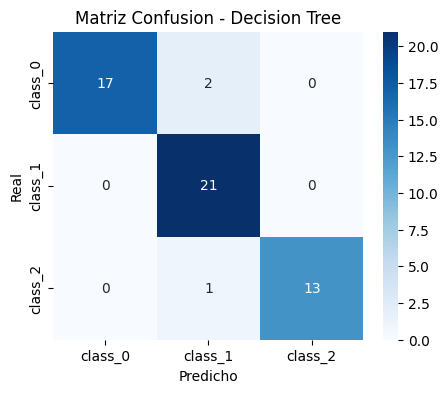

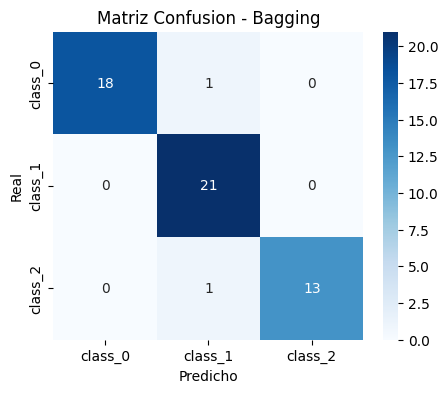

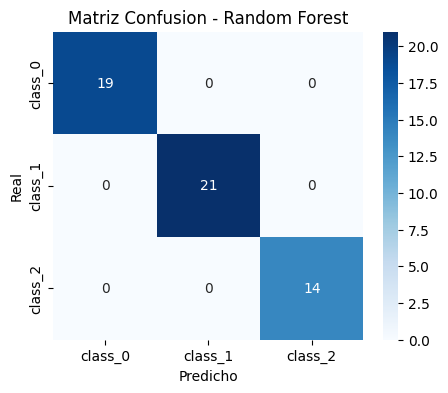

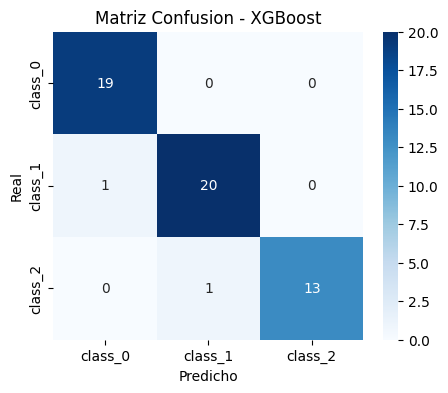

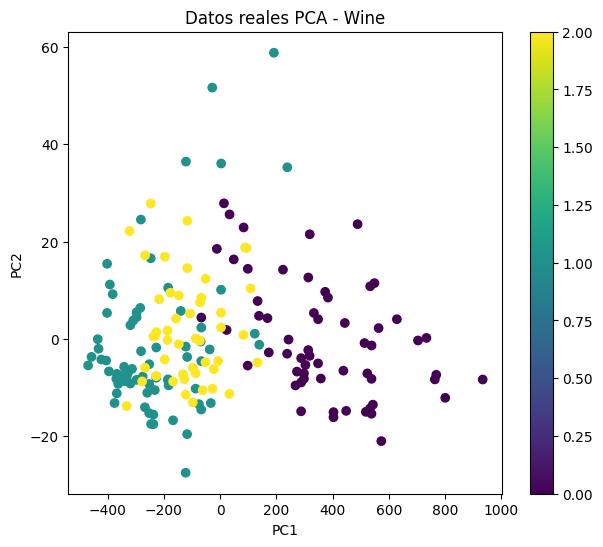

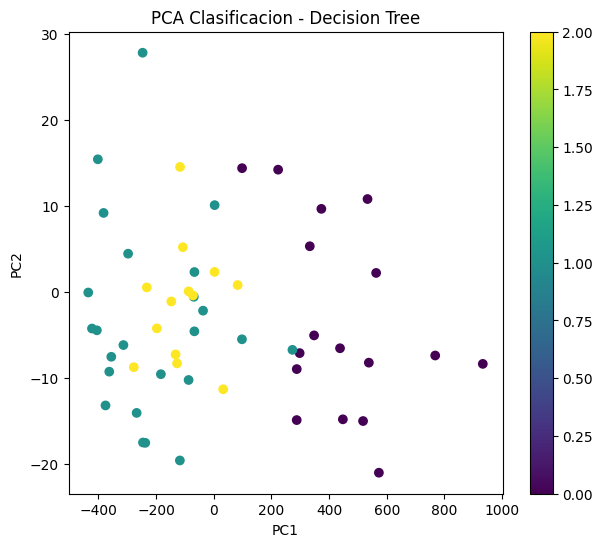

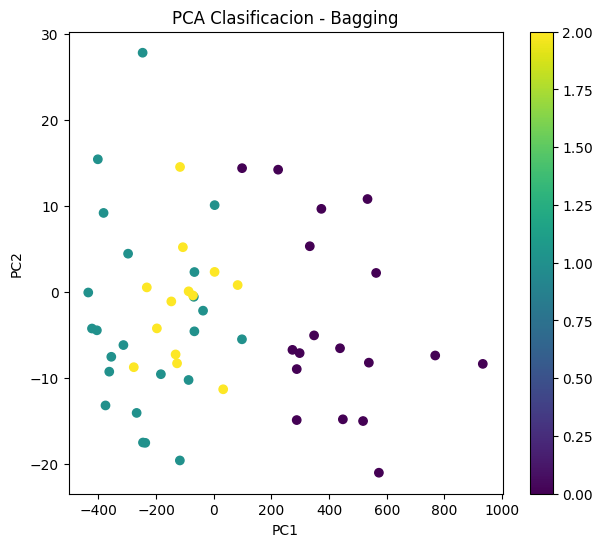

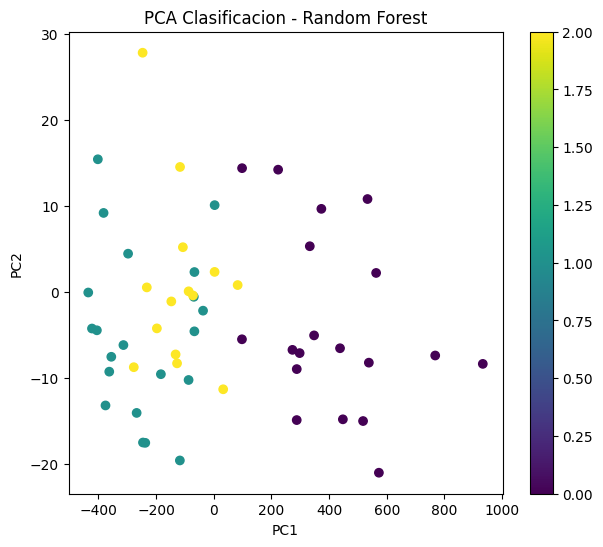

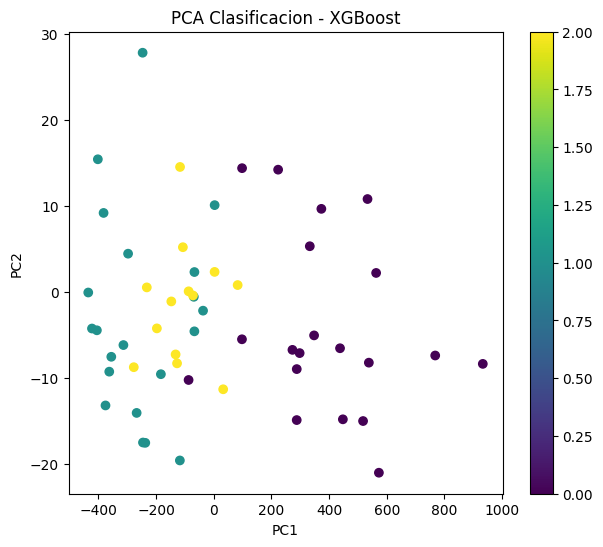

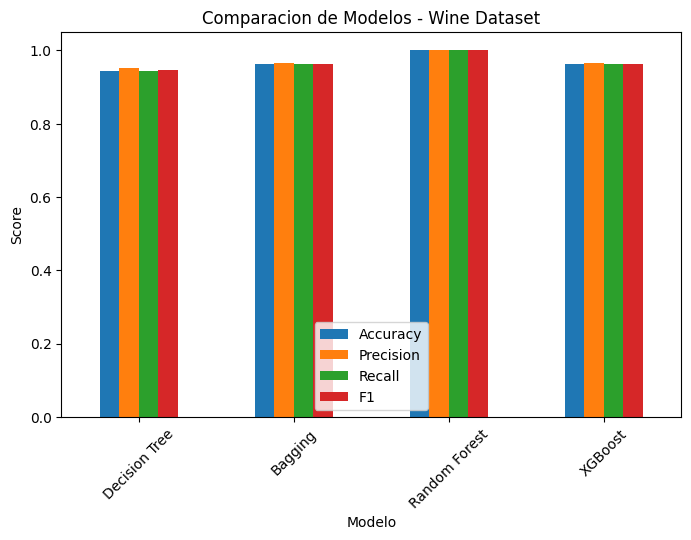


MEJOR MODELO

Modelo       Random Forest
Accuracy               1.0
Precision              1.0
Recall                 1.0
F1                     1.0
Name: 2, dtype: object


In [17]:

# ======================================
# COMPARACION DE MODELOS - DATASET WINE
# ======================================

# !pip install xgboost seaborn scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ======================================
# 1 CARGAR DATOS
# ======================================

wine = load_wine()

X = wine.data
y = wine.target

feature_names = wine.feature_names
class_names = wine.target_names

# ======================================
# 2 TRAIN TEST
# ======================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# ======================================
# 3 MODELOS
# ======================================

models = {

"Decision Tree":
DecisionTreeClassifier(max_depth=4),

"Bagging":
BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100
),

"Random Forest":
RandomForestClassifier(
    n_estimators=100
),

"XGBoost":
xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    objective="multi:softprob",
    num_class=3
)

}

# ======================================
# 4 ENTRENAR Y EVALUAR
# ======================================

results = []
predictions = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    predictions[name] = y_pred

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average="weighted")
    rec = recall_score(y_test, y_pred, average="weighted")
    f1 = f1_score(y_test, y_pred, average="weighted")

    results.append([name, acc, prec, rec, f1])

results_df = pd.DataFrame(
    results,
    columns=["Modelo","Accuracy","Precision","Recall","F1"]
)

print("\nTABLA COMPARATIVA\n")
print(results_df)

# ======================================
# 5 MATRIZ DE CONFUSION
# ======================================

for name, y_pred in predictions.items():

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5,4))

    sns.heatmap(
        cm,
        annot=True,
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names
    )

    plt.title(f"Matriz Confusion - {name}")
    plt.xlabel("Predicho")
    plt.ylabel("Real")
    plt.show()

# ======================================
# 6 PCA VISUALIZACION
# ======================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plt.figure(figsize=(7,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=y,
    cmap="viridis"
)

plt.title("Datos reales PCA - Wine")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.colorbar()
plt.show()

# ======================================
# 7 PCA PREDICCION
# ======================================

X_test_pca = pca.transform(X_test)

for name, y_pred in predictions.items():

    plt.figure(figsize=(7,6))

    plt.scatter(
        X_test_pca[:,0],
        X_test_pca[:,1],
        c=y_pred,
        cmap="viridis"
    )

    plt.title(f"PCA Clasificacion - {name}")
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.colorbar()

    plt.show()

# ======================================
# 8 GRAFICO COMPARATIVO
# ======================================

results_df.set_index("Modelo").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Comparacion de Modelos - Wine Dataset")
plt.ylabel("Score")
plt.xticks(rotation=45)

plt.show()

# ======================================
# 9 MEJOR MODELO
# ======================================

best = results_df.sort_values(
    by="Accuracy",
    ascending=False
).iloc[0]

print("\nMEJOR MODELO\n")
print(best)


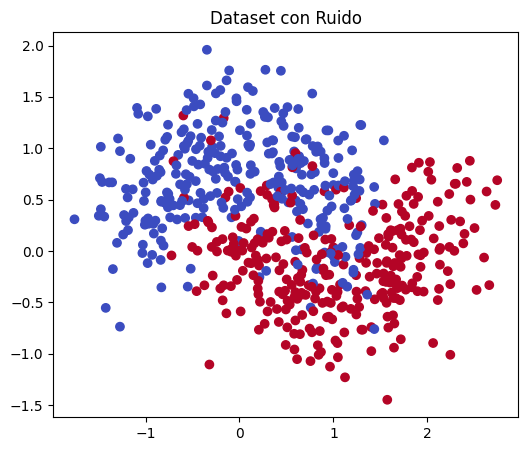


TABLA COMPARATIVA

          Modelo  Accuracy  Precision    Recall        F1
0  Decision Tree  0.861111   0.872093  0.842697  0.857143
1        Bagging  0.844444   0.858824  0.820225  0.839080
2  Random Forest  0.850000   0.860465  0.831461  0.845714
3        XGBoost  0.844444   0.867470  0.808989  0.837209


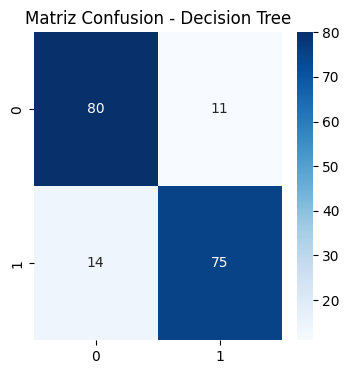

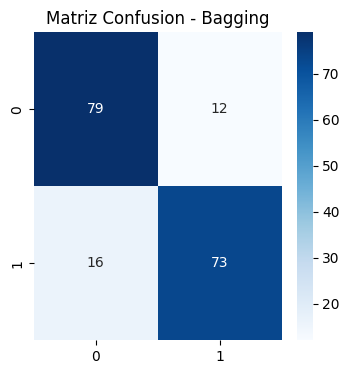

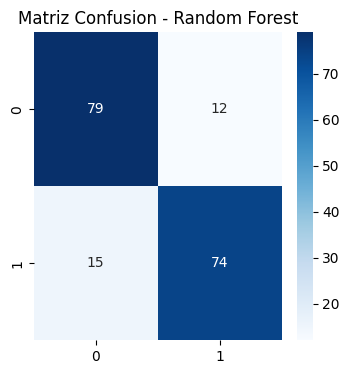

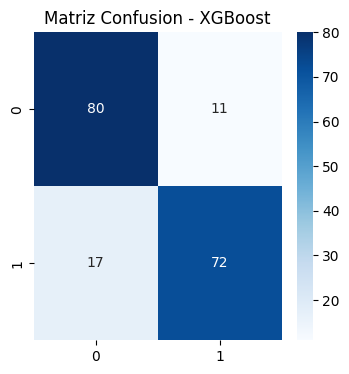

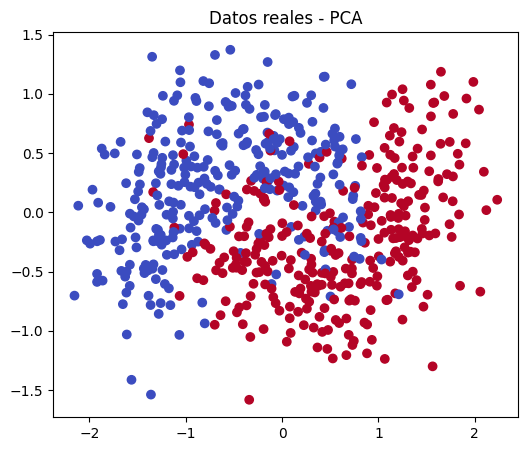

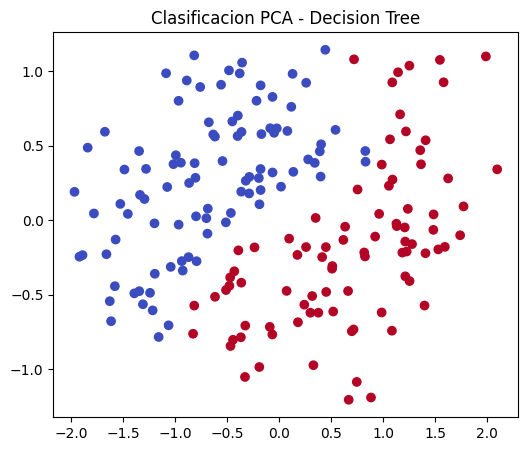

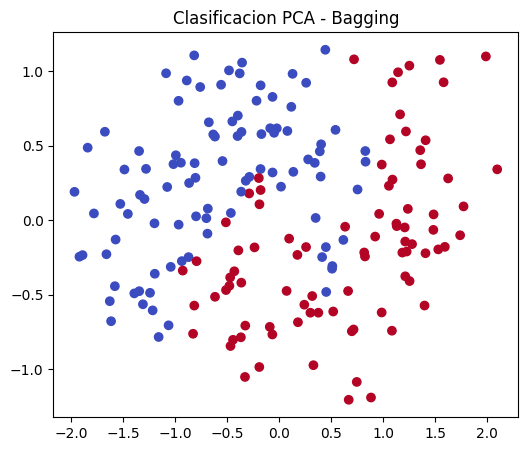

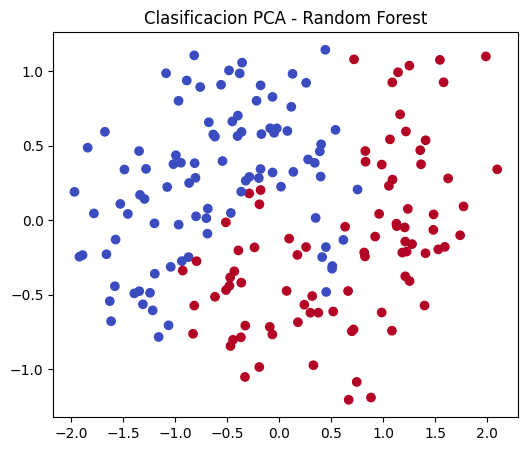

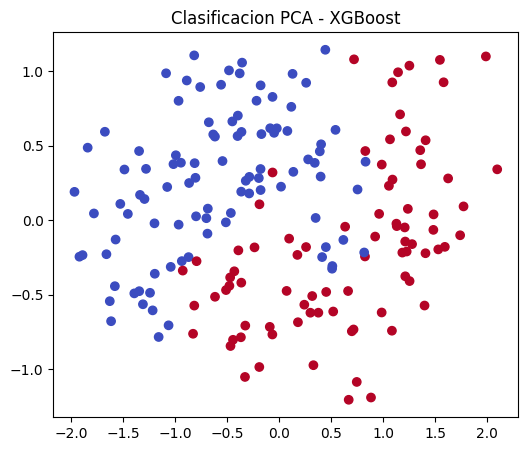

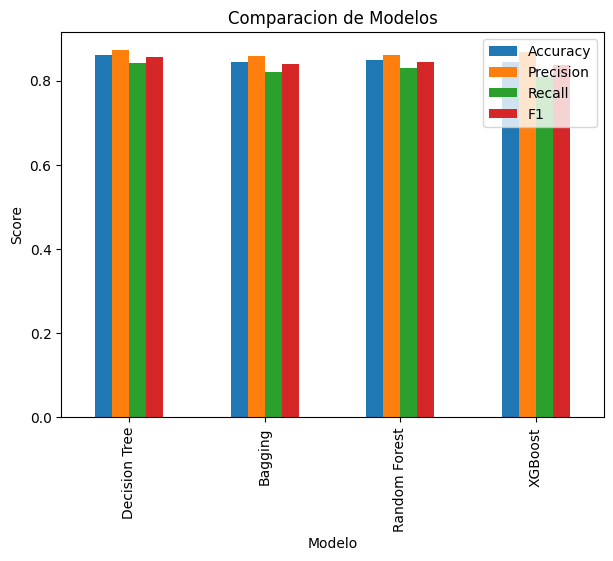


MEJOR MODELO

Modelo       Decision Tree
Accuracy          0.861111
Precision         0.872093
Recall            0.842697
F1                0.857143
Name: 0, dtype: object


In [18]:

# ==========================================
# COMPARACION DE MODELOS - DATASET CON RUIDO
# ==========================================

# !pip install xgboost seaborn scikit-learn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import RandomForestClassifier

import xgboost as xgb

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ==========================================
# 1 GENERAR DATASET CON RUIDO
# ==========================================

X, y = make_moons(
    n_samples=600,
    noise=0.35,   # ruido para hacerlo dificil
    random_state=42
)

# visualizar datos

plt.figure(figsize=(6,5))

plt.scatter(X[:,0], X[:,1], c=y, cmap="coolwarm")

plt.title("Dataset con Ruido")
plt.show()

# ==========================================
# 2 TRAIN TEST
# ==========================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=42
)

# ==========================================
# 3 MODELOS
# ==========================================

models = {

"Decision Tree":
DecisionTreeClassifier(max_depth=4),

"Bagging":
BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=100
),

"Random Forest":
RandomForestClassifier(
    n_estimators=100
),

"XGBoost":
xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1
)

}

# ==========================================
# 4 ENTRENAR Y EVALUAR
# ==========================================

results = []
predictions = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    predictions[name] = y_pred

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append([name, acc, prec, rec, f1])

results_df = pd.DataFrame(
    results,
    columns=["Modelo","Accuracy","Precision","Recall","F1"]
)

print("\nTABLA COMPARATIVA\n")
print(results_df)

# ==========================================
# 5 MATRICES DE CONFUSION
# ==========================================

for name, y_pred in predictions.items():

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(4,4))

    sns.heatmap(
        cm,
        annot=True,
        cmap="Blues"
    )

    plt.title(f"Matriz Confusion - {name}")
    plt.show()

# ==========================================
# 6 PCA
# ==========================================

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X)

plt.figure(figsize=(6,5))

plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="coolwarm")

plt.title("Datos reales - PCA")
plt.show()

# ==========================================
# 7 PCA CON PREDICCIONES
# ==========================================

X_test_pca = pca.transform(X_test)

for name, y_pred in predictions.items():

    plt.figure(figsize=(6,5))

    plt.scatter(
        X_test_pca[:,0],
        X_test_pca[:,1],
        c=y_pred,
        cmap="coolwarm"
    )

    plt.title(f"Clasificacion PCA - {name}")
    plt.show()

# ==========================================
# 8 COMPARACION DE METRICAS
# ==========================================

results_df.set_index("Modelo").plot(
    kind="bar",
    figsize=(7,5)
)

plt.title("Comparacion de Modelos")
plt.ylabel("Score")
plt.show()

# ==========================================
# 9 MEJOR MODELO
# ==========================================

best = results_df.sort_values(
    by="Accuracy",
    ascending=False
).iloc[0]

print("\nMEJOR MODELO\n")
print(best)


# Árboles de Decisión para Series de Tiempo

## 1. Introducción

Las **series de tiempo** consisten en observaciones ordenadas temporalmente

[
{y_t}_{t=1}^{T}
]

donde (t) representa el tiempo.

El objetivo principal es modelar la dependencia temporal para realizar **predicción**

[
\hat{y}_{t+h}
]

donde (h) es el horizonte de predicción.

Los **árboles de decisión para series de tiempo** extienden los métodos de clasificación y regresión para capturar **relaciones no lineales entre rezagos de la serie**.

---

# 2. Representación con Variables Rezagadas

Una serie temporal puede representarse mediante un vector de **lags**.

Para un orden (p):

[
x_t =
(y_{t-1},y_{t-2},\dots,y_{t-p})
]

Entonces el problema se convierte en un problema de regresión:

[
y_t = f(x_t) + \varepsilon_t
]

donde

[
\varepsilon_t \sim (0,\sigma^2)
]

y (f(\cdot)) se aproxima mediante un **árbol de regresión**.

---

# 3. Árboles de Regresión

Un árbol divide el espacio de predictores en regiones

[
R_1,R_2,\dots,R_M
]

y el modelo predice

[
\hat{y} =
\sum_{m=1}^{M}
c_m I(x \in R_m)
]

donde

[
c_m =
\frac{1}{|R_m|}
\sum_{x_i \in R_m}
y_i
]

es el promedio en la región.

---

# 4. Función de Pérdida

Para árboles de regresión se minimiza el error cuadrático

[
RSS =
\sum_{i=1}^{n}
(y_i - \hat{y}_i)^2
]

Cada división del árbol se elige para minimizar

[
RSS_{split} =
\sum_{x_i \in R_1}
(y_i - c_1)^2
+
\sum_{x_i \in R_2}
(y_i - c_2)^2
]

---

# 5. Modelo Autorregresivo con Árboles

Una forma común de aplicar árboles a series de tiempo es

[
y_t =
f(y_{t-1},y_{t-2},\dots,y_{t-p}) + \varepsilon_t
]

Esto generaliza el modelo **AR(p)** clásico:

[
y_t =
\phi_1 y_{t-1}
+
\phi_2 y_{t-2}
+
\dots
+
\phi_p y_{t-p}
+
\varepsilon_t
]

pero permite **relaciones no lineales**.

---

# 6. Árboles para Regímenes Temporales

Los árboles pueden detectar **cambios de régimen** en series de tiempo.

Por ejemplo

[
y_t =
\begin{cases}
f_1(y_{t-1}) + \varepsilon_t & y_{t-1} < c \
f_2(y_{t-1}) + \varepsilon_t & y_{t-1} \ge c
\end{cases}
]

Esto se relaciona con modelos **TAR (Threshold Autoregressive)**.

---

# 7. Ensambles para Series de Tiempo

Los métodos más utilizados son:

### Random Forest

[
\hat{y}*t =
\frac{1}{B}
\sum*{b=1}^{B}
T_b(x_t)
]

---

### Gradient Boosting

[
F_m(x) =
F_{m-1}(x)
+
\nu h_m(x)
]

---

### XGBoost

Optimiza

[
\mathcal{L} =
\sum_{t=1}^{T}
l(y_t,\hat{y}_t)
+
\sum_k
\Omega(f_k)
]

---

# 8. Validación en Series de Tiempo

A diferencia de datos independientes, en series de tiempo no se puede usar validación aleatoria.

Se utiliza **validación temporal**:

[
Train = {1,\dots,t}
]

[
Test = {t+1,\dots,t+h}
]

o **rolling window**.

---

# 9. Ventajas de Árboles en Series de Tiempo

* capturan **no linealidades**
* detectan **cambios de régimen**
* manejan **interacciones complejas**
* funcionan bien con **muchos predictores**

---

# 10. Limitaciones

* pueden ignorar estructura temporal si no se usan rezagos
* requieren **ingeniería de variables**
* menor interpretabilidad en ensambles grandes.

---


Los árboles de decisión proporcionan una alternativa flexible a los modelos clásicos de series de tiempo como ARIMA. Al modelar funciones no lineales de los rezagos de la serie, permiten capturar patrones complejos y cambios estructurales en los datos temporales.



TABLA COMPARATIVA

          Modelo       RMSE        MAE       MAPE
0  Decision Tree  80.794583  54.586172  11.080796
1        Bagging  69.468537  52.765000  11.053288
2  Random Forest  67.391711  51.402857  10.828497
3       Boosting  80.680441  60.632360  12.537965
4          ARIMA  84.598032  68.382667  15.793726


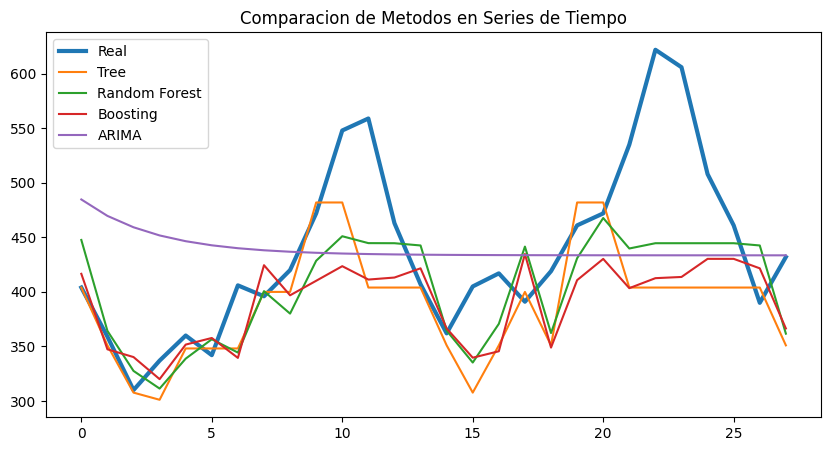

In [22]:
# ==========================================
# SERIES DE TIEMPO - COMPARACION DE METODOS
# ==========================================

# !pip install pandas numpy scikit-learn matplotlib statsmodels xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error

from statsmodels.tsa.arima.model import ARIMA

# ==========================================
# 1 CARGAR SERIE
# ==========================================

import statsmodels.api as sm

data = sm.datasets.get_rdataset("AirPassengers").data

ts = data["value"].values

# ==========================================
# 2 CREAR LAGS
# ==========================================

def create_lags(series, lags=4):

    df = pd.DataFrame()

    df["y"] = series[lags:]

    for i in range(1, lags+1):
        df[f"lag{i}"] = series[lags-i:-i]

    return df

df = create_lags(ts,4)

# ==========================================
# 3 TRAIN TEST
# ==========================================

train_size = int(len(df)*0.8)

train = df.iloc[:train_size]
test = df.iloc[train_size:]

X_train = train.drop("y",axis=1)
y_train = train["y"]

X_test = test.drop("y",axis=1)
y_test = test["y"]

# ==========================================
# 4 MODELOS
# ==========================================

tree = DecisionTreeRegressor(max_depth=4)

bagging = BaggingRegressor(
    estimator=DecisionTreeRegressor(),
    n_estimators=200
)

rf = RandomForestRegressor(
    n_estimators=200
)

boost = GradientBoostingRegressor(
    n_estimators=200
)

# ==========================================
# 5 ENTRENAR
# ==========================================

tree.fit(X_train,y_train)
bagging.fit(X_train,y_train)
rf.fit(X_train,y_train)
boost.fit(X_train,y_train)

# ==========================================
# 6 PREDICCIONES
# ==========================================

pred_tree = tree.predict(X_test)
pred_bag = bagging.predict(X_test)
pred_rf = rf.predict(X_test)
pred_boost = boost.predict(X_test)

# ==========================================
# 7 ARIMA
# ==========================================

train_ts = ts[:train_size+4]
test_ts = ts[train_size+4:]

arima = ARIMA(train_ts,order=(2,1,2)).fit()

pred_arima = arima.forecast(len(test_ts))

# ==========================================
# 8 METRICAS
# ==========================================

def metrics(y,yp):

    rmse = np.sqrt(mean_squared_error(y,yp))
    mae = mean_absolute_error(y,yp)
    mape = np.mean(np.abs((y-yp)/y))*100

    return rmse,mae,mape

results = []

models = {
"Decision Tree":pred_tree,
"Bagging":pred_bag,
"Random Forest":pred_rf,
"Boosting":pred_boost
}

for name,p in models.items():

    rmse,mae,mape = metrics(y_test,p)

    results.append([name,rmse,mae,mape])

rmse,mae,mape = metrics(test_ts,pred_arima)

results.append(["ARIMA",rmse,mae,mape])

results_df = pd.DataFrame(
results,
columns=["Modelo","RMSE","MAE","MAPE"]
)

print("\nTABLA COMPARATIVA\n")
print(results_df)

# ==========================================
# 9 GRAFICO
# ==========================================

plt.figure(figsize=(10,5))

plt.plot(test_ts,label="Real",linewidth=3)

plt.plot(pred_tree,label="Tree")
plt.plot(pred_rf,label="Random Forest")
plt.plot(pred_boost,label="Boosting")
plt.plot(pred_arima,label="ARIMA")

plt.legend()

plt.title("Comparacion de Metodos en Series de Tiempo")

plt.show()